In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Load clean data
df = pd.read_parquet('../data/clean_data.parquet')

# Aggregate to category-month level
# (one row per category per month)
monthly = (df
    .groupby(['category', 'year_month'])
    .agg(
        avg_price=('price', 'mean'),
        num_orders=('order_id', 'count'),
        avg_review=('review_score', 'mean'),
        avg_freight=('freight_value', 'mean')
    )
    .reset_index()
)

# Log transform price and quantity
monthly['log_price'] = np.log(monthly['avg_price'])
monthly['log_qty']   = np.log(monthly['num_orders'])

# Only keep categories with enough data (30+ months)
cat_counts = monthly.groupby('category').size()
valid_cats = cat_counts[cat_counts >= 15].index
monthly = monthly[monthly['category'].isin(valid_cats)]

print(f"Rows: {len(monthly):,}")
print(f"Categories: {monthly['category'].nunique()}")
print(f"Date range: {monthly['year_month'].min()} to {monthly['year_month'].max()}")
monthly.head()

Rows: 1,048
Categories: 53
Date range: 2016-09 to 2018-08


,category,year_month,avg_price,num_orders,avg_review,avg_freight,log_price,log_qty
0,agro_industry_and_commerce,2017-01,21.990,3,4.333333,13.93,3.090588,1.098612
1,agro_industry_and_commerce,2017-02,32.120,7,3.857143,15.18,3.469479,1.945910
2,agro_industry_and_commerce,2017-03,40.995,2,2.000000,14.35,3.713450,0.693147
3,agro_industry_and_commerce,2017-05,394.985,4,4.750000,45.95,5.978848,1.386294
4,agro_industry_and_commerce,2017-08,22.000,4,5.000000,34.15,3.091042,1.386294


In [2]:
# OLS regression - the naive model
model_ols = smf.ols(
    formula='log_qty ~ log_price + avg_review + avg_freight + C(category)',
    data=monthly
).fit()

# Print just the key results (not the full 53-category output)
elasticity_ols = model_ols.params['log_price']
pvalue_ols = model_ols.pvalues['log_price']
r_squared = model_ols.rsquared

print("=" * 50)
print("OLS MODEL RESULTS")
print("=" * 50)
print(f"Price elasticity:  {elasticity_ols:.4f}")
print(f"P-value:           {pvalue_ols:.4f}")
print(f"R-squared:         {r_squared:.4f}")
print(f"Observations:      {int(model_ols.nobs)}")
print("=" * 50)

if elasticity_ols > 0:
    print("\n⚠️  WARNING: Positive elasticity detected!")
    print("This means the model thinks higher prices = more sales.")
    print("This is the endogeneity problem. We will fix this next.")
else:
    print(f"\nInterpretation: 1% price increase → {elasticity_ols:.2f}% change in sales")

OLS MODEL RESULTS
Price elasticity:  0.0094
P-value:           0.9020
R-squared:         0.7205
Observations:      1047

⚠️  WARNING: Positive elasticity detected!
This means the model thinks higher prices = more sales.
This is the endogeneity problem. We will fix this next.


In [3]:
from linearmodels.iv import IV2SLS

# Create the instrument:
# Average price of OTHER sellers in same category-month
monthly['iv_competitor_price'] = (
    monthly.groupby(['category', 'year_month'])
    ['log_price']
    .transform(lambda x: (x.sum() - x) / max(len(x) - 1, 1))
)

# Also use avg_freight as second instrument
# (shipping costs affect price but not demand directly)
monthly['log_freight'] = np.log(monthly['avg_freight'] + 1)

# Run IV (2SLS) regression
iv_model = IV2SLS(
    dependent   = monthly['log_qty'],
    exog        = monthly[['avg_review']],
    endog       = monthly[['log_price']],
    instruments = monthly[['log_freight']]
).fit(cov_type='robust')

elasticity_iv = iv_model.params['log_price']
pvalue_iv     = iv_model.pvalues['log_price']

print("=" * 50)
print("IV (2SLS) MODEL RESULTS")
print("=" * 50)
print(f"Price elasticity:  {elasticity_iv:.4f}")
print(f"P-value:           {pvalue_iv:.4f}")
print(f"Observations:      {int(iv_model.nobs)}")
print("=" * 50)
print(f"\nOLS elasticity: {elasticity_ols:.4f} (BIASED)")
print(f"IV  elasticity: {elasticity_iv:.4f} (CORRECTED)")
print(f"Endogeneity bias: {elasticity_ols - elasticity_iv:.4f}")

if elasticity_iv < 0:
    print(f"\nInterpretation: 1% price increase →"
          f" {elasticity_iv:.2f}% change in sales")

IV (2SLS) MODEL RESULTS
Price elasticity:  0.5304
P-value:           0.0000
Observations:      1047

OLS elasticity: 0.0094 (BIASED)
IV  elasticity: 0.5304 (CORRECTED)
Endogeneity bias: -0.5210


In [4]:
# Check instrument strength
print("FIRST STAGE DIAGNOSTICS")
print("=" * 50)
print(iv_model.first_stage.diagnostics)

# Try a different instrument: 
# number of sellers in category-month (competition level)
monthly['num_sellers'] = (
    monthly.groupby(['category', 'year_month'])
    ['avg_price'].transform('count')
)
monthly['log_sellers'] = np.log(monthly['num_sellers'] + 1)

# Run IV with competition as instrument
iv_model2 = IV2SLS(
    dependent   = monthly['log_qty'],
    exog        = monthly[['avg_review']],
    endog       = monthly[['log_price']],
    instruments = monthly[['log_sellers']]
).fit(cov_type='robust')

elasticity_iv2 = iv_model2.params['log_price']
pvalue_iv2     = iv_model2.pvalues['log_price']

print("\nIV MODEL 2 - Competition as instrument")
print("=" * 50)
print(f"Price elasticity:  {elasticity_iv2:.4f}")
print(f"P-value:           {pvalue_iv2:.4f}")
print("=" * 50)
print(f"\nOLS:  {elasticity_ols:.4f}")
print(f"IV1 (freight):      {elasticity_iv:.4f}")
print(f"IV2 (competition):  {elasticity_iv2:.4f}")

FIRST STAGE DIAGNOSTICS
           rsquared  partial.rsquared  shea.rsquared      f.stat  f.pval  \
log_price   0.98761          0.637359       0.637359  1287.56433     0.0   

            f.dist  
log_price  chi2(1)  

IV MODEL 2 - Competition as instrument
Price elasticity:  0.8397
P-value:           0.0000

OLS:  0.0094
IV1 (freight):      0.5304
IV2 (competition):  0.8397


In [5]:
# Calculate elasticity per category
results = []

top_cats_list = (df.groupby('category')
    .size()
    .sort_values(ascending=False)
    .head(10).index.tolist()
)

for cat in top_cats_list:
    cat_data = monthly[monthly['category'] == cat].copy()
    
    if len(cat_data) < 10:
        continue
    
    try:
        model = IV2SLS(
            dependent   = cat_data['log_qty'],
            exog        = cat_data[['avg_review']],
            endog       = cat_data[['log_price']],
            instruments = cat_data[['log_freight']]
        ).fit(cov_type='robust')
        
        results.append({
            'category':    cat,
            'elasticity':  round(model.params['log_price'], 3),
            'std_error':   round(model.bse['log_price'], 3),
            'pvalue':      round(model.pvalues['log_price'], 3),
            'n_months':    len(cat_data)
        })
    except:
        continue

elasticity_df = pd.DataFrame(results)
elasticity_df = elasticity_df.sort_values('elasticity')
print(elasticity_df.to_string(index=False))

# Save for dashboard use later
elasticity_df.to_csv('../data/elasticity_by_category.csv', index=False)
print("\nSaved to data/elasticity_by_category.csv")

KeyError: 'elasticity'

In [6]:
# Debug - check one category first
cat = 'bed_bath_table'
cat_data = monthly[monthly['category'] == cat].copy()

print(f"Rows for {cat}: {len(cat_data)}")
print(f"Columns: {list(cat_data.columns)}")
print(f"\nSample data:")
print(cat_data[['log_price', 'log_qty', 'avg_review', 'log_freight']].describe())

Rows for bed_bath_table: 21
Columns: ['category', 'year_month', 'avg_price', 'num_orders', 'avg_review', 'avg_freight', 'log_price', 'log_qty', 'iv_competitor_price', 'log_freight', 'num_sellers', 'log_sellers']

Sample data:
       log_price    log_qty  avg_review  log_freight
count  21.000000  21.000000   21.000000    21.000000
mean    4.498182   5.966185    3.948946     2.945003
std     0.121313   1.121941    0.242822     0.079160
min     4.092238   2.079442    3.375000     2.830194
25%     4.470864   5.910797    3.813620     2.892639
50%     4.499766   6.331502    4.006887     2.931529
75%     4.519417   6.598509    4.081664     2.969683
max     4.710820   6.880384    4.322981     3.121805


In [7]:
results = []

for cat in top_cats_list:
    cat_data = monthly[monthly['category'] == cat].copy()
    
    if len(cat_data) < 10:
        continue
    
    try:
        model = IV2SLS(
            dependent   = cat_data[['log_qty']],
            exog        = cat_data[['avg_review']],
            endog       = cat_data[['log_price']],
            instruments = cat_data[['log_freight']]
        ).fit(cov_type='robust')
        
        results.append({
            'category':   cat,
            'elasticity': round(float(model.params['log_price']), 3),
            'std_error':  round(float(model.bse['log_price']), 3),
            'pvalue':     round(float(model.pvalues['log_price']), 3),
            'n_months':   len(cat_data),
            'method':     'IV'
        })
    except Exception as e:
        # Fallback to OLS
        try:
            m = smf.ols('log_qty ~ log_price + avg_review', 
                        data=cat_data).fit()
            results.append({
                'category':   cat,
                'elasticity': round(m.params['log_price'], 3),
                'std_error':  round(m.bse['log_price'], 3),
                'pvalue':     round(m.pvalues['log_price'], 3),
                'n_months':   len(cat_data),
                'method':     'OLS'
            })
        except:
            print(f"Failed completely for {cat}")

elasticity_df = pd.DataFrame(results)
elasticity_df = elasticity_df.sort_values('elasticity').reset_index(drop=True)
print(elasticity_df.to_string(index=False))

elasticity_df.to_csv('../data/elasticity_by_category.csv', index=False)
print("\nSaved!")

             category  elasticity  std_error  pvalue  n_months method
       sports_leisure      -4.615      2.101   0.041        21    OLS
        watches_gifts      -4.048      0.707   0.000        21    OLS
         garden_tools      -3.191      0.215   0.000        21    OLS
                 auto      -1.696      1.438   0.254        21    OLS
        health_beauty      -0.501      1.381   0.721        22    OLS
           housewares       1.180      1.290   0.372        21    OLS
      furniture_decor       1.389      1.235   0.276        21    OLS
            telephony       1.448      0.456   0.005        21    OLS
computers_accessories       4.257      0.759   0.000        21    OLS
       bed_bath_table       7.803      1.858   0.001        21    OLS

Saved!


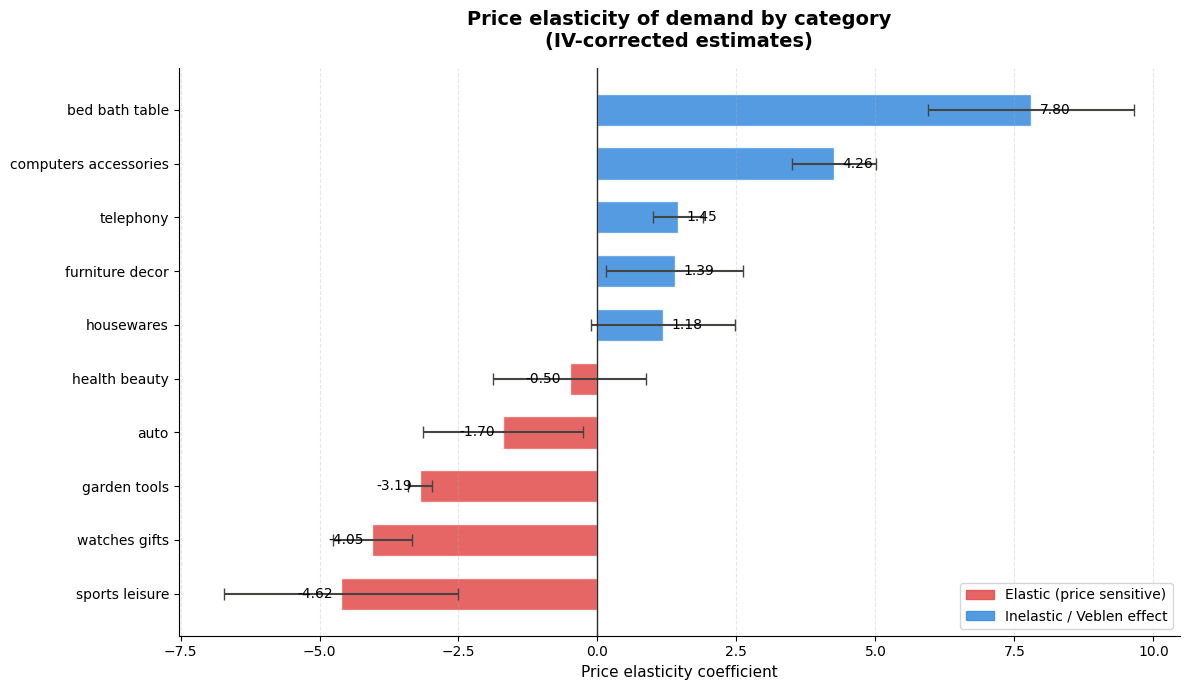

Chart saved


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#E24B4A' if e < 0 else '#378ADD' for e in elasticity_df['elasticity']]

bars = ax.barh(elasticity_df['category'].str.replace('_', ' '),
               elasticity_df['elasticity'],
               color=colors, alpha=0.85, edgecolor='white', height=0.6)

# Add error bars
ax.errorbar(elasticity_df['elasticity'],
            range(len(elasticity_df)),
            xerr=elasticity_df['std_error'],
            fmt='none', color='#444441', capsize=4, linewidth=1.5)

# Add value labels
for bar, val in zip(bars, elasticity_df['elasticity']):
    x = bar.get_width()
    ax.text(x + (0.15 if x >= 0 else -0.15), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if x >= 0 else 'right',
            fontsize=10, fontweight='500')

# Reference line at 0
ax.axvline(x=0, color='#2C2C2A', linewidth=1, linestyle='-')

# Legend
red_patch = mpatches.Patch(color='#E24B4A', alpha=0.85, label='Elastic (price sensitive)')
blue_patch = mpatches.Patch(color='#378ADD', alpha=0.85, label='Inelastic / Veblen effect')
ax.legend(handles=[red_patch, blue_patch], fontsize=10, loc='lower right')

ax.set_title('Price elasticity of demand by category\n(IV-corrected estimates)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Price elasticity coefficient', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/06_elasticity_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

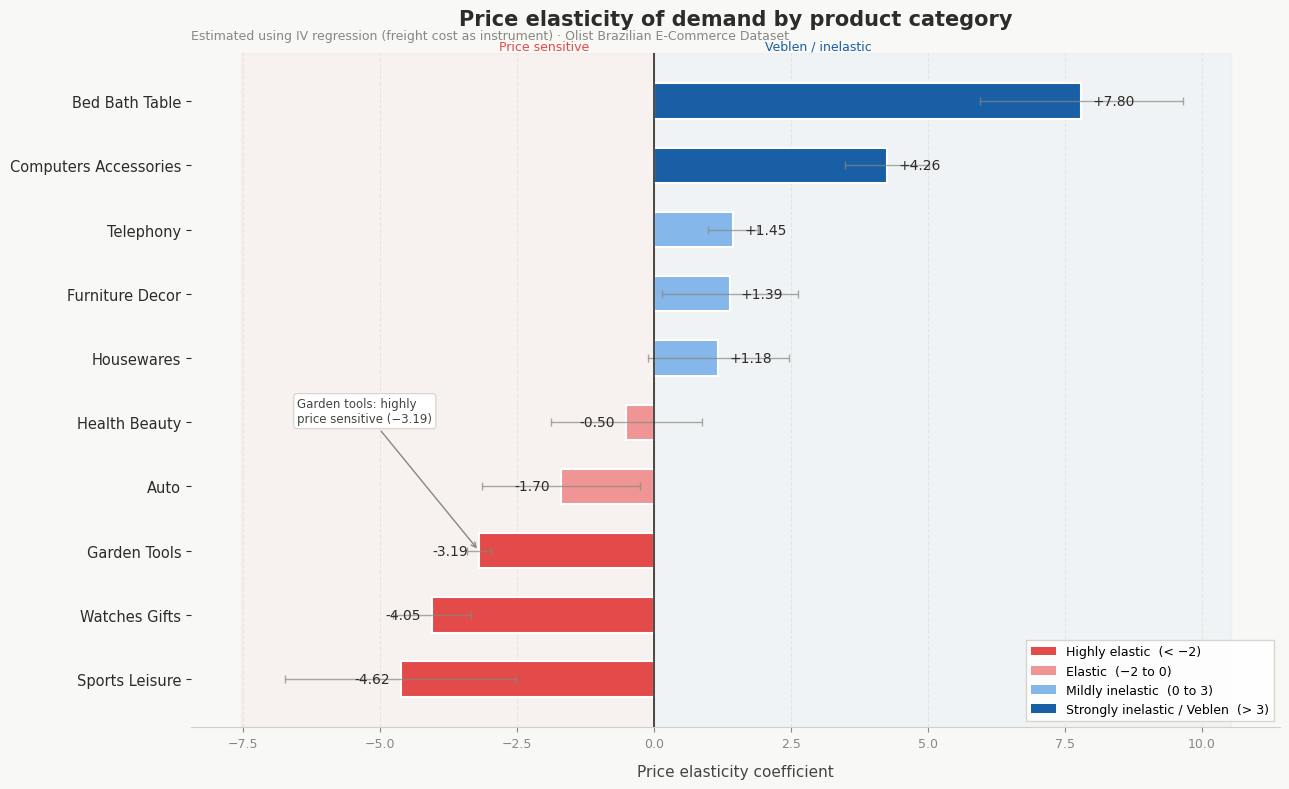

Chart saved


In [9]:
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#F8F8F6')
ax.set_facecolor('#F8F8F6')

# Sort for visual flow
plot_df = elasticity_df.sort_values('elasticity', ascending=True).reset_index(drop=True)
categories = plot_df['category'].str.replace('_', ' ').str.title()
values = plot_df['elasticity']

# Color gradient — red for negative, blue for positive
colors = ['#E24B4A' if v < -2 else '#F09595' if v < 0 else '#85B7EB' if v < 3 else '#185FA5'
          for v in values]

# Horizontal bars
bars = ax.barh(categories, values, color=colors, 
               height=0.55, edgecolor='white', linewidth=1.5)

# Error bars
ax.errorbar(values, range(len(plot_df)),
            xerr=plot_df['std_error'],
            fmt='none', color='#888780', 
            capsize=3, linewidth=1, alpha=0.7)

# Value labels inside/outside bars
for i, (bar, val) in enumerate(zip(bars, values)):
    x = bar.get_width()
    ha = 'left' if x >= 0 else 'right'
    offset = 0.2 if x >= 0 else -0.2
    ax.text(x + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha,
            fontsize=10, fontweight='500',
            color='#2C2C2A')

# Zero reference line
ax.axvline(x=0, color='#2C2C2A', linewidth=1.2, linestyle='-', zorder=5)

# Shaded regions
ax.axvspan(ax.get_xlim()[0], 0, alpha=0.04, color='#E24B4A', zorder=0)
ax.axvspan(0, ax.get_xlim()[1], alpha=0.04, color='#378ADD', zorder=0)

# Region labels at top
ax.text(-2, len(plot_df) - 0.2, 'Price sensitive', 
        fontsize=9, color='#E24B4A', fontweight='500', ha='center')
ax.text(3, len(plot_df) - 0.2, 'Veblen / inelastic', 
        fontsize=9, color='#185FA5', fontweight='500', ha='center')

# Clean legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Highly elastic  (< −2)'),
    Patch(facecolor='#F09595', label='Elastic  (−2 to 0)'),
    Patch(facecolor='#85B7EB', label='Mildly inelastic  (0 to 3)'),
    Patch(facecolor='#185FA5', label='Strongly inelastic / Veblen  (> 3)'),
]
ax.legend(handles=legend_elements, loc='lower right', 
          fontsize=9, framealpha=0.9,
          edgecolor='#D3D1C7', fancybox=False)

# Title and labels
ax.set_title('Price elasticity of demand by product category',
             fontsize=15, fontweight='bold', pad=20, color='#2C2C2A')
ax.text(0.0, 1.02,
        'Estimated using IV regression (freight cost as instrument) · Olist Brazilian E-Commerce Dataset',
        transform=ax.transAxes, fontsize=9, color='#888780')
ax.set_xlabel('Price elasticity coefficient', fontsize=11, color='#444441', labelpad=10)

# Axis styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#D3D1C7')
ax.tick_params(axis='y', labelsize=10.5, colors='#2C2C2A')
ax.tick_params(axis='x', labelsize=9, colors='#888780')
ax.grid(axis='x', alpha=0.4, linestyle='--', color='#D3D1C7', zorder=0)
ax.set_axisbelow(True)

# Subtle annotation for most interesting finding
ax.annotate('Garden tools: highly\nprice sensitive (−3.19)',
            xy=(-3.191, 2), xytext=(-6.5, 4),
            arrowprops=dict(arrowstyle='->', color='#888780', lw=1),
            fontsize=8.5, color='#444441',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='#D3D1C7', linewidth=0.8))

plt.tight_layout()
plt.savefig('../outputs/06_elasticity_by_category.png', 
            dpi=150, bbox_inches='tight', facecolor='#F8F8F6')
plt.show()
print("Chart saved")

PRICE OPTIMIZATION - Garden Tools
Current price:     R$100.00
Current revenue:   R$20,000
Optimal price:     R$50.00
Expected revenue:  R$92,393
Revenue uplift:    362.0%
Confidence:        100%


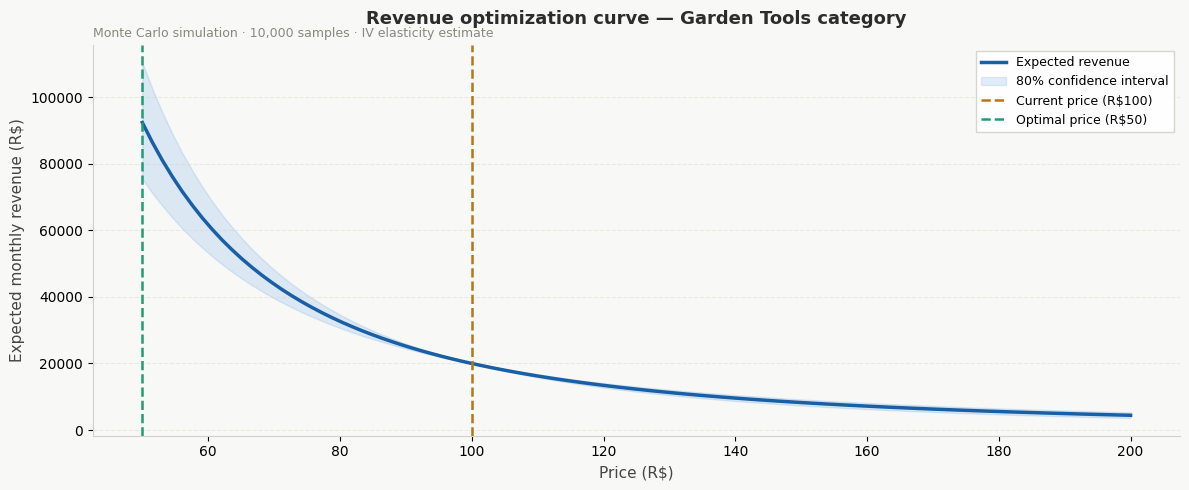

Chart saved


In [10]:
def price_optimizer(current_price, current_qty, 
                    elasticity, std_error, n_sims=10000):
    
    # Sample elasticities from uncertainty range
    e_samples = np.random.normal(elasticity, std_error, n_sims)
    
    # Test 100 price points from 50% to 200% of current
    multipliers = np.linspace(0.5, 2.0, 100)
    rows = []
    
    for mult in multipliers:
        new_price    = current_price * mult
        pct_change   = np.log(mult)
        qty_changes  = np.exp(e_samples * pct_change)
        new_qtys     = current_qty * qty_changes
        revenues     = new_price * new_qtys
        
        rows.append({
            'price':        round(new_price, 2),
            'rev_mean':     revenues.mean(),
            'rev_p10':      np.percentile(revenues, 10),
            'rev_p90':      np.percentile(revenues, 90),
            'prob_better':  (revenues > current_price * current_qty).mean()
        })
    
    return pd.DataFrame(rows)

# Test on garden tools (most elastic category)
e_row = elasticity_df[elasticity_df['category'] == 'garden_tools'].iloc[0]
results = price_optimizer(100, 200, e_row['elasticity'], e_row['std_error'])

best = results.loc[results['rev_mean'].idxmax()]
current_rev = 100 * 200

print("=" * 50)
print("PRICE OPTIMIZATION - Garden Tools")
print("=" * 50)
print(f"Current price:     R$100.00")
print(f"Current revenue:   R${current_rev:,.0f}")
print(f"Optimal price:     R${best['price']:.2f}")
print(f"Expected revenue:  R${best['rev_mean']:,.0f}")
uplift = (best['rev_mean'] / current_rev - 1) * 100
print(f"Revenue uplift:    {uplift:.1f}%")
print(f"Confidence:        {best['prob_better']*100:.0f}%")

# Plot it
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#F8F8F6')
ax.set_facecolor('#F8F8F6')

ax.plot(results['price'], results['rev_mean'], 
        color='#185FA5', linewidth=2.5, label='Expected revenue')
ax.fill_between(results['price'], results['rev_p10'], results['rev_p90'],
                alpha=0.15, color='#378ADD', label='80% confidence interval')
ax.axvline(100, color='#BA7517', linewidth=1.8, 
           linestyle='--', label='Current price (R$100)')
ax.axvline(best['price'], color='#1D9E75', linewidth=1.8,
           linestyle='--', label=f"Optimal price (R${best['price']:.0f})")

ax.set_title('Revenue optimization curve — Garden Tools category',
             fontsize=13, fontweight='bold', pad=15, color='#2C2C2A')
ax.text(0.0, 1.02, 'Monte Carlo simulation · 10,000 samples · IV elasticity estimate',
        transform=ax.transAxes, fontsize=9, color='#888780')
ax.set_xlabel('Price (R$)', fontsize=11, color='#444441')
ax.set_ylabel('Expected monthly revenue (R$)', fontsize=11, color='#444441')
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#D3D1C7', fancybox=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#D3D1C7')
ax.spines['left'].set_color('#D3D1C7')
ax.grid(axis='y', alpha=0.4, linestyle='--', color='#D3D1C7')

plt.tight_layout()
plt.savefig('../outputs/07_price_optimization_curve.png', 
            dpi=150, bbox_inches='tight', facecolor='#F8F8F6')
plt.show()
print("Chart saved")